Step size h = 0.01
Eigenvalues: [1.+0.01j 1.-0.01j]
Solution may not be Entirely Stable ;)

Step size h = 0.1
Eigenvalues: [1.+0.1j 1.-0.1j]
Solution may not be Entirely Stable ;)

Step size h = 0.5
Eigenvalues: [1.+0.5j 1.-0.5j]
Solution may not be Entirely Stable ;)

Step size h = 1.0
Eigenvalues: [1.+1.j 1.-1.j]
Solution may not be Entirely Stable ;)



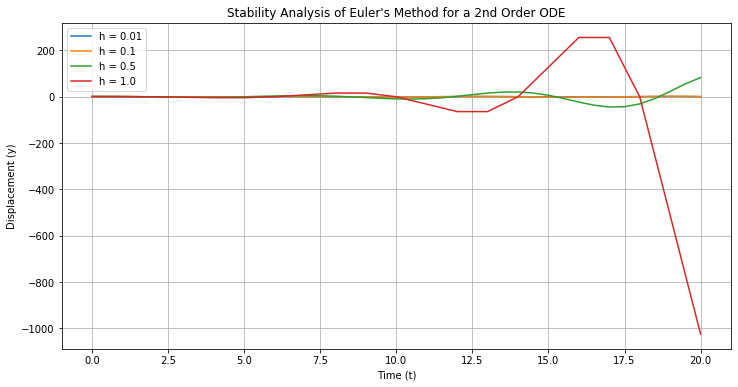

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
k = 1.0
h_values = [0.01, 0.1, 0.5, 1.0]
t_start = 0
t_end = 20
y_0 = 1.0
v_0 = 0.0

# Function to apply Euler's Method for given step size
def euler_method(h, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))

    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]

        # Update equations for Euler's Method
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)

    return t_values, y_values

# Plot results for different step sizes
plt.figure(figsize=(12, 6))

for h in h_values:
    # Construct coefficient matrix
    A = np.array([
        [1, h],
        [-h * k, 1]
    ])

    # Compute eigenvalues using built-in function
    eigenvalues = np.linalg.eigvals(A)
    magnitudes = np.abs(eigenvalues)

    # Output step size and stability message
    print(f"Step size h = {h}")
    print("Eigenvalues:", eigenvalues)

    if np.all(magnitudes < 1):
        print("Solution is Stable")
    else:
        print("Solution may not be Entirely Stable ;)")
    print()

    # Simulate and plot
    t, y = euler_method(h, k, t_start, t_end, y_0, v_0)
    plt.plot(t, y, label=f'h = {h}')

plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title("Stability Analysis of Euler's Method for a 2nd Order ODE")
plt.legend()
plt.grid(True)
plt.show()